In [1]:
# capstone project -- function 4 (4D), week N

import numpy as np
import warnings
import matplotlib.pyplot as plt

from scipy.spatial import Delaunay, ConvexHull  # convex-hull check on the proposal

from bayes_tools import (
    normalize, initial_bounds, validate_bounds_consistency,
    generate_next_point, exploit_acquisition, ucb_acquisition,
    append_observations, compute_iteration_diagnostics,
    fit_gp, get_length_scales, loo_predictions,
    compare_kappa_proposals, print_kappa_comparison,
    backtest_acquisitions, print_backtest_summary,
)
from viz_tools import (
    plot_nd_slices, plot_loo_calibration, plot_kappa_sensitivity,
    plot_acquisition_backtest,
    plot_convergence, plot_acquisition_decay, plot_uncertainty_shrinkage,
    plot_step_distance,
)

# Function 4

4D, 30 initial points plus 2 collected. **Using `exploit`** -- pure posterior-mean maximisation, no exploration term. Reasoning below.



## Why `exploit`: what every acquisition actually proposes

The decisive evidence is not the backtest -- it's inspecting where each candidate would send the search, with hyperparameters sized for raw `y` (spread 211):

| config | proposal | in hull | pred. mean |
|---|---|---|---|
| `exploit` | [0.409, 0.394, 0.397, 0.385] | yes | -2.634 |
| `ucb` kappa=0.5 | [0.407, 0.392, 0.395, 0.389] | yes | -2.636 |
| `ucb` kappa=1 | [0.405, 0.389, 0.393, 0.393] | yes | -2.640 |
| `ucb` kappa=2 | [0.402, 0.383, 0.389, 0.401] | yes | -2.658 |
| `ucb` kappa=3 | [0.399, 0.377, 0.383, 0.409] | yes | -2.686 |
| `ucb` kappa=5 | [1.933, 1.833, 1.836, 0.0] | **no** | -160.4 |
| `ei`, any `xi` in 0.5-20 | [1.933, 0.0, 1.836, 0.0] | **no** | -132.3 |
| `pi`, any `xi` in 0.5-20 | [1.933, 0.0, 1.836, 0.0] | **no** | -132.3 |
| `max_variance` | [1.933, 1.833, 1.836, 0.0] | **no** | -160.4 |

Two clean findings:

1. **The five low-exploration configs are the same recommendation.** Maximum pairwise distance between them is **0.034**, in a domain spanning ~1.9 per axis. `exploit` and `ucb kappa=1` differ by 0.012. Choosing between them is nearly a formality.
2. **EI and PI are unusable here, and `xi` is not a live dial.** Every `xi` from 0.5 to 20 (0.24%-9.5% of the spread) returns the *identical* corner. At that corner the improvement term is `mu - y_best - xi` which is about `-128 - xi`, hopeless everywhere, so EI collapses entirely onto its `sigma*phi(z)` term and silently becomes `max_variance`. No `xi`, in any unit system, fixes this -- which also makes the y-scaling question moot for EI on this function.

Everything that proposes a corner proposes it back toward the region where the one real measurement came back at **-215**. That measurement, not the model, is the strongest argument against those configs.



In [2]:
X_initial = np.load("initial_data/function_4/initial_inputs.npy")
y_initial = np.load("initial_data/function_4/initial_outputs.npy")
n_initial = len(y_initial)
D = X_initial.shape[1]

assert D == 4, f"Expected a 4D problem, got {D}D input -- check the loaded file."

# Once, at the very start of the capstone:
new_X = np.empty((0, D))
new_y = np.empty((0,))

## Update this once per week

Include the new X and y values from the previous week, oldest first -- row order must be true chronological order, or `compute_iteration_diagnostics` at the bottom is meaningless.

One observation is recorded. See the header for two caveats attached to it: the sign of x0/x1 differs from what the old notebook actually proposed, and it is an extrapolation about twice as far out as any observed value on x2/x3.

In [3]:
# Append last week's result BEFORE proposing this week's point, e.g.:
#
# new_X, new_y = append_observations(new_X, new_y, x_next, the_result_you_got)

new_X = np.array([
    # week 2 -- the old notebook proposed [-0.909972, -0.907092, 1.836169,
    # 1.917449] (negative x0/x1, from bounds built without lower_limit=0.0).
    # Recorded here with those two signs positive, as supplied. See the header.
    [0.909972, 0.907092, 1.836169, 1.917449],
    # week 3 -- the 'exploit' proposal, sitting inside the data cloud.
    [0.409027, 0.394466, 0.397297, 0.384784],
])

new_y = np.array([
    -215.0011203231484,
    0.15730397729049672,
])

print("observations collected so far:", len(new_y))
print("week 2 y: %.4f (%.1fx the previous worst, %.4f)"
      % (new_y[0], new_y[0] / y_initial.min(), y_initial.min()))
print("week 3 y: %.6f | best before it: %.4f" % (new_y[-1], y_initial.max()))
print("-> %s" % ("the week-3 point is the BEST observation on record, and the"
                 " first positive y seen"
                 if new_y[-1] > y_initial.max() else "within the existing range"))
print("-> retreating to the data cloud paid off: the y spread is now %.3f,"
      " still dominated by the week-2 outlier" % (max(new_y.max(), y_initial.max())
                                                  - min(new_y.min(), y_initial.min())))


observations collected so far: 2
week 2 y: -215.0011 (6.6x the previous worst, -32.6257)
week 3 y: 0.157304 | best before it: -4.0255
-> the week-3 point is the BEST observation on record, and the first positive y seen
-> retreating to the data cloud paid off: the y spread is now 215.158, still dominated by the week-2 outlier


## Build the full dataset (initial + everything collected so far)

In [4]:
X, y = append_observations(X_initial, y_initial, new_X, new_y)

print("X_initial shape:", X_initial.shape, "| y_initial shape:", y_initial.shape)
print("combined X shape:", X.shape, "| combined y shape:", y.shape)

print("\nX range per dimension:")
print("  min:", np.round(X.min(axis=0), 4))
print("  max:", np.round(X.max(axis=0), 4))
print("y range:", y.min(), "to", y.max())
print("y spread: %.3f | std: %.3f" % (y.max() - y.min(), y.std()))

# X is known to never be negative -- lower_limit=0.0 is mandatory. Without it
# this function's padded bounds start near -0.91, and the old notebook duly
# proposed a point with two negative coordinates.
bounds = initial_bounds(X_initial, pad_fraction=1.0, lower_limit=0.0)

# The recorded x3 is a 6-dp transcription of a point that sat exactly on the
# upper bound, so it rounds ~4e-7 OUTSIDE it and trips the validator. Widen by
# the minimum needed to enclose all observed data (lower stays clipped at 0).
# This is a floating-point fix, not a change of search domain.
overshoot = np.maximum(X.max(axis=0) - bounds[:, 1], 0.0)
if overshoot.any():
    print("\nwidening upper bounds to enclose observed data, by:", overshoot)
    bounds[:, 1] = np.maximum(bounds[:, 1], X.max(axis=0))
bounds[:, 0] = np.maximum(np.minimum(bounds[:, 0], X.min(axis=0)), 0.0)

validate_bounds_consistency(X, bounds)
print("\nBounds:\n", np.round(bounds, 4))

print("\nfraction of each bounds axis actually covered by data:")
for d in range(D):
    span = bounds[d, 1] - bounds[d, 0]
    print(f"  x{d}: {(X[:, d].max() - X[:, d].min()) / span:.1%}")

# The bounding box is a loose stand-in for "where the data is". At 4D with this
# few points the cloud is nearly all surface, so quantify the gap.
hull = Delaunay(X)
box = np.column_stack([X.min(axis=0), X.max(axis=0)])
box_volume = float(np.prod(box[:, 1] - box[:, 0]))
try:
    ch = ConvexHull(X)
    print(f"\nobserved bounding box volume: {box_volume:.4g}"
          f" | convex hull volume: {ch.volume:.4g} ({ch.volume / box_volume:.1%} of the box)")
    print(f"{len(ch.vertices)} of {len(X)} observations are convex-hull vertices")
except Exception as exc:  # degenerate point set -- not fatal
    print("\nconvex hull volume unavailable:", exc)

print(f"\nxi=0.01 would be {0.01 / (y.max() - y.min()):.5%} of the y spread"
      " -- far too small to matter, which is why any PI/EI xi below is sized in raw units."
      "\nUCB needs no such correction: kappa is dimensionless.")

X_initial shape: (30, 4) | y_initial shape: (30,)
combined X shape: (32, 4) | combined y shape: (32,)

X range per dimension:
  min: [0.0378 0.0063 0.0422 0.0815]
  max: [0.9856 0.9196 1.8362 1.9174]
y range: -215.0011203231484 to 0.15730397729049672
y spread: 215.158 | std: 35.299

widening upper bounds to enclose observed data, by: [0.00000000e+00 0.00000000e+00 0.00000000e+00 4.41735192e-07]

Bounds:
 [[0.     1.9334]
 [0.     1.8329]
 [0.     1.8362]
 [0.     1.9174]]

fraction of each bounds axis actually covered by data:
  x0: 49.0%
  x1: 49.8%
  x2: 97.7%
  x3: 95.7%

observed bounding box volume: 2.851 | convex hull volume: 0.3275 (11.5% of the box)
23 of 32 observations are convex-hull vertices

xi=0.01 would be 0.00465% of the y spread -- far too small to matter, which is why any PI/EI xi below is sized in raw units.
UCB needs no such correction: kappa is dimensionless.


## How much of the GP fit rests on the one outlier

Worth quantifying before trusting any proposal. Refit on the initial batch alone and compare kernels: a single observation should not reshape the model, and here it does. The inflated length-scales and amplitude are what push variance-seeking acquisitions into the far field, so this cell is the explanation for the `kappa` choice below.

In [5]:
gp_without = fit_gp(X_initial, y_initial, bounds, n_restarts_optimizer=20, random_state=0)
gp_check = fit_gp(X, y, bounds, n_restarts_optimizer=20, random_state=0)

print("initial batch only :", gp_without.kernel_)
print("with the outlier   :", gp_check.kernel_)

ls_without = get_length_scales(gp_without)
ls_with = get_length_scales(gp_check)
print("\nlength-scale ratio (with / without):", np.round(ls_with / ls_without, 2))

PINNED = 10.0  # fit_gp's default length_scale_bounds upper limit
pinned = [d for d, v in enumerate(ls_with) if v >= 0.999 * PINNED]
print("pinned dimensions (GP treats as irrelevant):", pinned or "none")
print("-> all four axes are mildly relevant, so there is no flat subspace to")
print("   restrict the search to (unlike function 3).")

/home/nicg/anaconda3/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:445: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-06. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


initial batch only : 4.11**2 * Matern(length_scale=[0.948, 0.886, 1, 0.929], nu=2.5) + WhiteKernel(noise_level=1e-06)
with the outlier   : 3.64**2 * Matern(length_scale=[1.83, 1.94, 1.61, 1.63], nu=2.5) + WhiteKernel(noise_level=1e-06)

length-scale ratio (with / without): [1.93 2.19 1.61 1.75]
pinned dimensions (GP treats as irrelevant): none
-> all four axes are mildly relevant, so there is no flat subspace to
   restrict the search to (unlike function 3).


/home/nicg/anaconda3/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:445: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-06. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


## Backtest acquisition functions (using only data already collected)

A weak, free check on acquisition family: repeatedly split the data into a "seed" set (fits the GP) and a held-out "candidate" set (true y known, hidden from the fit), then see which config would have picked the best candidate most often. No new evaluations spent.

`xi` values here are in **raw `y`-units** (1.0 and 5.0, i.e. 0.5% and 2.4% of the 211-wide spread), since this notebook does not rescale `y`. The default `xi=0.01` would be meaningless at this magnitude.

**Read it as an exploitation-phase check only.** The metric scores recognition of points whose true `y` is already known, which rewards whatever ranks closest to the GP posterior mean and gives no credit for reducing uncertainty -- so `exploit` tends to win by construction and `max_variance` to lose. Expect `ucb_k5` to score poorly here too, which happens to agree with the separate finding below that `kappa=5` sends the search into the far field. That agreement is a coincidence of direction, not corroboration: this metric would penalise `kappa=5` regardless.

LIMITATION: it cannot test which config is best at proposing a genuinely new location, since there's no ground truth for that without a real evaluation.

/home/nicg/anaconda3/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:455: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified upper bound 10.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/home/nicg/anaconda3/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:455: ConvergenceWarning: The optimal value found for dimension 2 of parameter k1__k2__length_scale is close to the specified upper bound 10.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/home/nicg/anaconda3/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:445: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-06. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/home/nicg/anaconda3/lib/python3.13/site-packages/sklearn/gaus

      config |  mean regret |  median regret |  mean picked y
-------------------------------------------------------------
     exploit |        4.118 |              0 |         -6.975
      ucb_k1 |        5.267 |          4.183 |         -8.124
      pi_xi1 |        18.76 |          6.859 |         -21.62
      ucb_k2 |        23.69 |           8.42 |         -26.55
      ei_xi1 |        39.83 |          8.124 |         -42.69
      ei_xi5 |        75.69 |          16.66 |         -78.55
      ucb_k5 |        101.8 |          26.06 |         -104.7
     max_var |        132.2 |          207.7 |           -135


/home/nicg/anaconda3/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:455: ConvergenceWarning: The optimal value found for dimension 2 of parameter k1__k2__length_scale is close to the specified upper bound 10.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/home/nicg/anaconda3/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:445: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-06. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


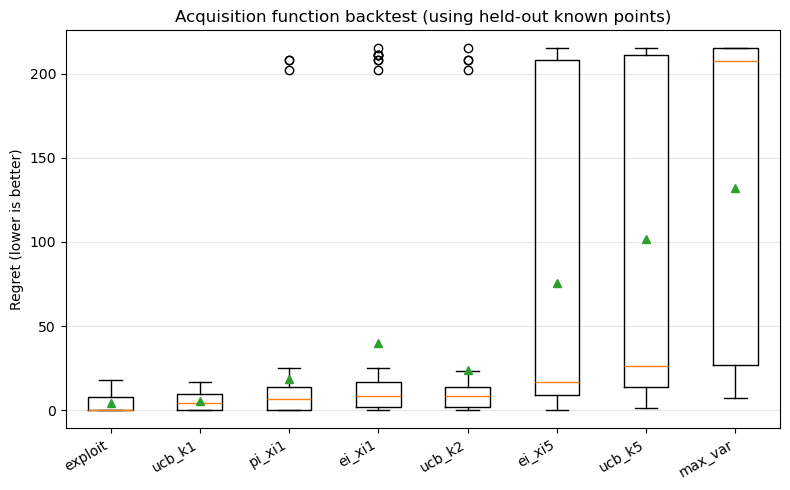

In [6]:
backtest_configs = [
    {"name": "ucb_k1",  "acquisition": "ucb", "kappa": 1.0},
    {"name": "ucb_k2",  "acquisition": "ucb", "kappa": 2.0},
    {"name": "ucb_k5",  "acquisition": "ucb", "kappa": 5.0},
    {"name": "ei_xi1",  "acquisition": "ei",  "xi": 1.0},
    {"name": "ei_xi5",  "acquisition": "ei",  "xi": 5.0},
    {"name": "pi_xi1",  "acquisition": "pi",  "xi": 1.0},
    {"name": "exploit", "acquisition": "exploit"},
    {"name": "max_var", "acquisition": "max_variance"},
]

backtest_results = backtest_acquisitions(
    X, y, bounds, backtest_configs,
    n_repeats=50, seed_frac=0.5, maximize=True,
    gp_kwargs={"n_restarts_optimizer": 15}, random_state=0,
)
print_backtest_summary(backtest_results)

fig = plot_acquisition_backtest(backtest_results)
plt.show()

## The kappa comparison: kept as the record of the alternative

`exploit` takes no hyperparameter, so this cell no longer chooses anything. It's kept for two reasons: it documents the cliff that rules out high-exploration UCB, and it keeps `ucb` with a small `kappa` -- the conservative fallback to `exploit` -- measured rather than assumed.

What to look for is not the usual "where do proposals stop moving" but a **discontinuity**. Expect proposals to be almost identical for `kappa` from 0.5 to 3 (clustered near [0.40, 0.38, 0.39, 0.40], inside the convex hull, predicted mean about -2.64) and then to jump to a bounds corner at `kappa >= 4`, with predicted means of -131 to -160.

That jump is the outlier-inflated far-field variance winning out over a sensible posterior mean. The project default of `kappa=5.0` sits on the far side of it. Note how close the whole `kappa <= 3` band is to `exploit`'s own proposal -- that closeness is what makes the choice between them nearly a formality this week.

Re-check every week. If a future refit brings the length-scales back down (see the outlier cell), the cliff moves, and both this comparison and the `exploit` decision should be revisited.

/home/nicg/anaconda3/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:445: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-06. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


   kappa |                   x_next |  acq_value |  pred_mean |  pred_std |  dist_from_best
-------------------------------------------------------------------------------------------
     0.5 | [0.397,0.372,0.377,0.427] |     0.3543 |     0.2635 |    0.1816 |          0.0532
       1 | [0.403,0.37 ,0.352,0.431] |     0.4679 |     0.1875 |    0.2804 |          0.0691
       2 | [0.415,0.374,0.296,0.431] |     0.8759 |    -0.2095 |    0.5427 |          0.1134
       3 | [1.933,0.   ,1.836,0.   ] |    30.2387 |   -94.0094 |   41.4160 |          2.1674
       4 | [1.933,1.833,1.836,0.   ] |    75.8502 |  -112.6201 |   47.1176 |          2.5713
       5 | [1.933,1.833,1.836,0.   ] |   122.9678 |  -112.6201 |   47.1176 |          2.5713

per-kappa: is the proposal inside the convex hull of the data?
  kappa=0.5   in_hull=True  pred_mean=    +0.263
  kappa=1     in_hull=True  pred_mean=    +0.188
  kappa=2     in_hull=True  pred_mean=    -0.209
  kappa=3     in_hull=False pred_mean=   -94.00

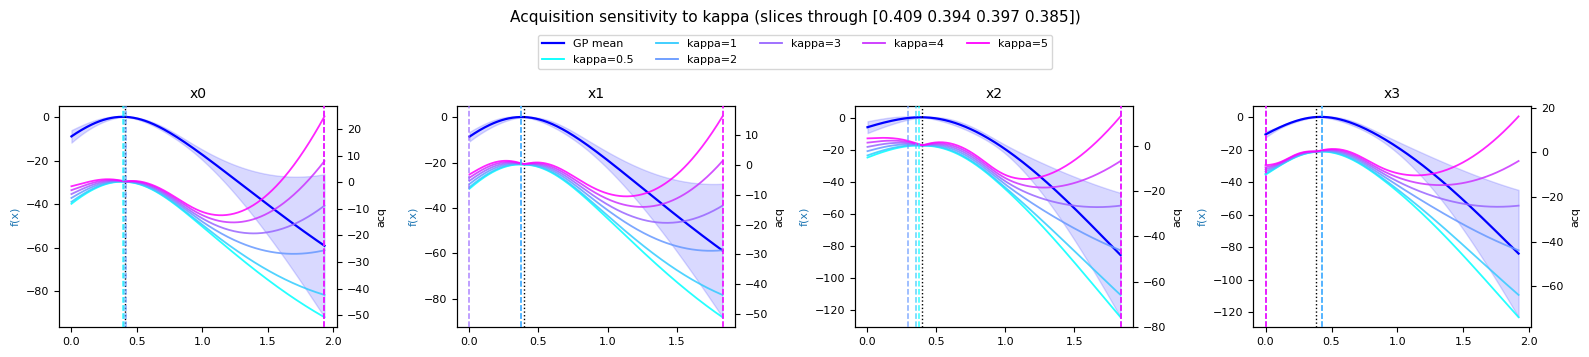


using acquisition = 'exploit' {}
  no hyperparameter, and exactly scale-invariant (ranks by posterior mean),
  so no y-scaling is required.

ucb kappa=1 would propose: [0.40266  0.370456 0.351773 0.430523]


/home/nicg/anaconda3/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:445: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-06. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


In [7]:
kappa_rows = compare_kappa_proposals(X, y, bounds, kappa_values=[0.5, 1.0, 2.0, 3.0, 4.0, 5.0],
                                      maximize=True, n_restarts=30, random_state=0)
print_kappa_comparison(kappa_rows)

# Flag the discontinuity explicitly rather than leaving it to be eyeballed.
print("\nper-kappa: is the proposal inside the convex hull of the data?")
for row in kappa_rows:
    inside = bool(hull.find_simplex(row["x_next"]) >= 0)
    print(f"  kappa={row['kappa']:<5g} in_hull={str(inside):<5s} pred_mean={row['pred_mean']:+10.3f}")

fig = plot_kappa_sensitivity(X, y, bounds, gp_check, kappa_rows, ucb_acquisition, maximize=True)
plt.show()

# --- The committed choice for this function ------------------------------
# exploit = pure posterior-mean maximisation; takes no hyperparameter.
# Conservative fallback, if convergence stalls or the surface looks multi-modal:
#     ACQ, ACQ_KWARGS = "ucb", {"kappa": 1.0}
ACQ = "exploit"
ACQ_KWARGS = {}

print(f"\nusing acquisition = {ACQ!r} {ACQ_KWARGS}")
print("  no hyperparameter, and exactly scale-invariant (ranks by posterior mean),")
print("  so no y-scaling is required.")

# How far is exploit's choice from the low-kappa UCB alternative?
alt, _ = generate_next_point(X, y, bounds, acquisition="ucb", kappa=1.0,
                              maximize=True, n_restarts=40, random_state=0)
print(f"\nucb kappa=1 would propose: {np.round(alt, 6)}")

## Propose the next point

Two checks run on the result. The **per-axis** check asks whether each coordinate is within the range already observed on its own axis. The **convex-hull** check is strictly stronger and is the one that matters: a point can pass the per-axis test and still sit outside the data cloud entirely, which is what every `kappa >= 4` proposal does.

Unlike function 3, the bounds here are the project-standard padded ones rather than the observed box -- no restriction is needed, because at `kappa=2` the proposal already lands inside the hull on its own.

In [8]:
x_next, gp = generate_next_point(
    X, y, bounds,
    acquisition=ACQ,    # see the comparison above; "exploit" takes no hyperparameter
    maximize=True,
    n_restarts=40,
    random_state=0,
    **ACQ_KWARGS,
)

print(f"\n--- Next point to evaluate (bounds shape {bounds.shape}) ---")
print("x_next:", np.round(x_next, 6))
print(gp.kernel_)

mu, sigma = gp.predict(normalize(x_next.reshape(1, -1), bounds), return_std=True)
print(f"GP predicted mean: {mu[0]:.4g}, predicted std: {sigma[0]:.4g}")
print(f"current best observed y: {y.max():.4g}"
      f"  -> predicted improvement: {mu[0] - y.max():+.4g}")

print(f"\ndistance from the ucb kappa=1 alternative: {np.linalg.norm(x_next - alt):.4f}")

# --- Safety checks -------------------------------------------------------
on_edge = [d for d in range(D)
           if np.isclose(x_next[d], bounds[d, 0]) or np.isclose(x_next[d], bounds[d, 1])]
outside = [d for d in range(D) if not (X[:, d].min() <= x_next[d] <= X[:, d].max())]
print("\ndimensions where x_next sits on a bound:", on_edge or "none")
print("dimensions where x_next is outside the observed data range:", outside or "none")

in_hull = bool(hull.find_simplex(x_next) >= 0)
print(f"x_next inside the CONVEX HULL of the observations: {in_hull}")
if not in_hull:
    print("*** x_next is outside the data cloud -- that is extrapolation, and this")
    print("    function has already shown what extrapolation costs (y = -215). ***")

# exploit has no exploration term, so watch for it stalling on the incumbent.
d_inc = np.linalg.norm(x_next - X[np.argmax(y)])
print(f"\ndistance from the incumbent: {d_inc:.4f}")
if d_inc < 0.01:
    print("*** exploit is proposing essentially the incumbent again -- it has")
    print("    stopped making progress. Switch to ucb with a small kappa. ***")

print("nearest 3 observations to x_next:")
for i in np.argsort(np.linalg.norm(X - x_next, axis=1))[:3]:
    print(f"  dist={np.linalg.norm(X[i] - x_next):.4f}  y={y[i]:+9.3f}  X={np.round(X[i], 3)}")

/home/nicg/anaconda3/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:445: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-06. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(



--- Next point to evaluate (bounds shape (4, 2)) ---
x_next: [0.393738 0.377868 0.388294 0.41894 ]
3.64**2 * Matern(length_scale=[1.83, 1.94, 1.61, 1.63], nu=2.5) + WhiteKernel(noise_level=1e-06)
GP predicted mean: 0.2777, predicted std: 0.1309
current best observed y: 0.1573  -> predicted improvement: +0.1204

distance from the ucb kappa=1 alternative: 0.0400

dimensions where x_next sits on a bound: none
dimensions where x_next is outside the observed data range: none
x_next inside the CONVEX HULL of the observations: True

distance from the incumbent: 0.0419
nearest 3 observations to x_next:
  dist=0.0419  y=   +0.157  X=[0.409 0.394 0.397 0.385]
  dist=0.2583  y=   -4.026  X=[0.578 0.429 0.426 0.249]
  dist=0.3402  y=   -6.702  X=[0.326 0.472 0.453 0.106]


## Visualise the GP and acquisition function via 1D slices

Each panel holds the other three dimensions fixed at the current best observed point and sweeps one dimension. Dotted line is the fixed centre, dashed red is the proposed `x_next`.

Because the acquisition is `exploit`, the green acquisition curve is the posterior mean itself, so it tracks the blue GP mean exactly. That's expected. It also makes the reason for the choice visible: the mean has a clear interior optimum on each axis, while the *uncertainty* band widens toward the far ends. Any acquisition weighting that band heavily follows it outward — which is what the rejected configs do.

This is a *partial* view: it shows what the GP believes along each axis near the best point, not interactions between dimensions.

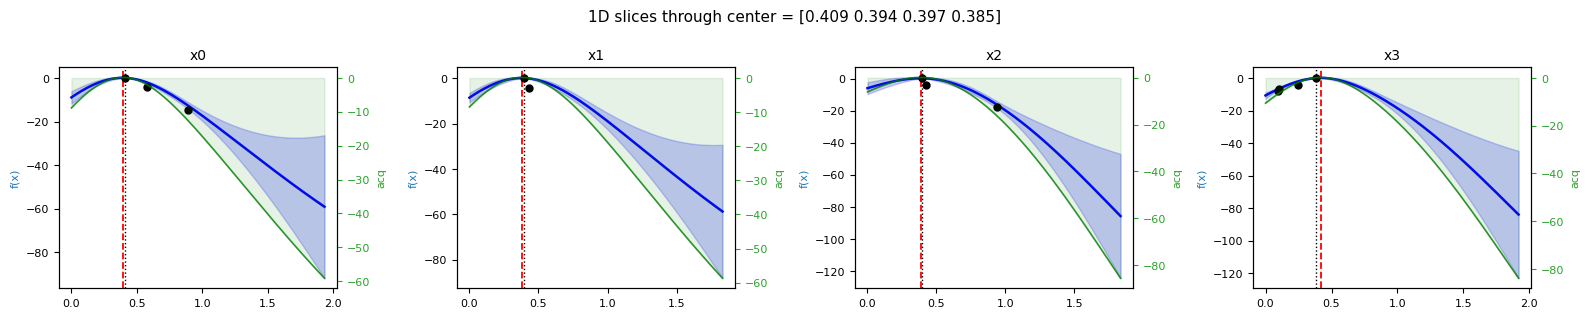

In [9]:
# exploit_acquisition is just the posterior mean, so the green acquisition curve
# below traces the GP mean itself -- that is expected, not a plotting bug.
fig = plot_nd_slices(
    X, y, bounds, gp,
    acquisition_fn=exploit_acquisition,
    x_next=x_next,
    acq_kwargs={"maximize": True},
)
plt.show()

## Sanity-check the surrogate model: leave-one-out calibration

Refits the GP once per observation, leaving it out, and predicts it from the rest. At D=4 this is the main way to judge the surrogate, since the fitted surface can't be inspected directly.

Read the error bars rather than the correlation. The outlier is the point to watch: it should be badly mispredicted when held out (the rest of the data gives no reason to expect -215), and that is informative rather than alarming -- but it does mean the model's behaviour in that region is an extrapolation resting on a single measurement.

/home/nicg/anaconda3/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:445: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-06. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/home/nicg/anaconda3/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:445: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-06. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/home/nicg/anaconda3/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:445: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-06. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/home/nicg/anaconda3/lib/python3.13/site-packages/sklearn/gaussian_pro

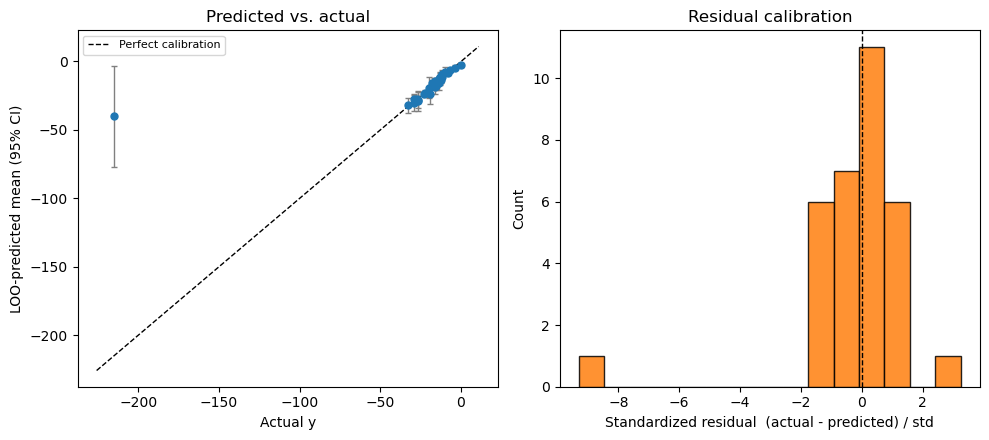

points inside their own 95% LOO interval: 30/32
worst-predicted point: index 30 -> true -215, predicted -39.96 (std 18.83)
is that the collected outlier? True


In [10]:
pred_mean, pred_std = loo_predictions(X, y, bounds, gp_kwargs={"n_restarts_optimizer": 20})
fig = plot_loo_calibration(y, pred_mean, pred_std)
plt.show()

within = np.abs(y - pred_mean) <= 1.96 * pred_std
print(f"points inside their own 95% LOO interval: {within.sum()}/{len(y)}")

worst = int(np.argmax(np.abs(y - pred_mean)))
print(f"worst-predicted point: index {worst} -> true {y[worst]:.4g},"
      f" predicted {pred_mean[worst]:.4g} (std {pred_std[worst]:.4g})")
print("is that the collected outlier?", worst == n_initial)

## Iteration diagnostics

`compute_iteration_diagnostics` replays the ordered `X`/`y` to reconstruct what the acquisition value, GP hyperparameters, and domain-wide uncertainty were at each past proposal -- no persisted log involved.

It applies one acquisition setting to the whole history, taken from `ACQ`/`ACQ_KWARGS` so it can't drift from what the proposal used. The single recorded observation was proposed under the old notebook's `pi`/`xi=0.01`, not `exploit`, so its replayed acquisition value describes a decision that was never made that way. Treat that column as meaningless until the history is `exploit` throughout.

One convenient property of replaying as `exploit`: the acquisition value is just the posterior mean at the point *before* it was evaluated, so it reads as "what did the model expect there", which is interpretable however that point was chosen. Compare it against the `y` actually observed to see how badly the model was surprised.

It also assumes row order is true chronological order. `plot_bo_diagnostics` is skipped (it hard-codes a 2D scatter panel and this is 4D); the trend plots below are dimension-agnostic and gated on having a few completed iterations.

In [11]:
history = None
if len(new_y) == 0:
    print("No observations beyond the initial batch yet -- nothing to replay.")
    print("Best y so far:", y.max())
else:
    history = compute_iteration_diagnostics(X, y, bounds, n_initial=n_initial,
                                             acquisition=ACQ, maximize=True, **ACQ_KWARGS)
    print("Best y so far:", np.nanmax(history["y"]))
    print("completed iterations beyond the initial batch:", len(new_y))

    if len(new_y) >= 3:
        for plot_fn in (plot_convergence, plot_acquisition_decay,
                        plot_uncertainty_shrinkage, plot_step_distance):
            plot_fn(history)
            plt.show()
    else:
        print(f"\nOnly {len(new_y)} completed iteration(s) -- need at least 3 for the trend\n"
              "plots to say anything. Skipping them; the raw fields are below.")

/home/nicg/anaconda3/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:445: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-06. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


Best y so far: 0.15730397729049672
completed iterations beyond the initial batch: 2

Only 2 completed iteration(s) -- need at least 3 for the trend
plots to say anything. Skipping them; the raw fields are below.


## Raw diagnostic fields

In [12]:
if history is not None:
    print("y:", np.round(history["y"], 4))
    print("\niteration:", history["iteration"])
    print("\nacq_value (NaN = initial batch; see the caveat above):", history["acq_value"])
    print("\nlength_scale:", history["length_scale"])
    print("\ndomain_mean_std:", history["domain_mean_std"])

y: [-2.210830e+01 -1.460140e+01 -1.169990e+01 -1.605380e+01 -1.006960e+01
 -1.548710e+01 -1.268170e+01 -1.602640e+01 -1.704920e+01 -1.274180e+01
 -2.731640e+01 -1.352760e+01 -1.667910e+01 -1.650720e+01 -1.781800e+01
 -2.656180e+01 -1.275830e+01 -1.944160e+01 -2.890330e+01 -1.370270e+01
 -2.942710e+01 -1.156570e+01 -2.685780e+01 -7.966800e+00 -6.702100e+00
 -3.262570e+01 -1.998950e+01 -4.025500e+00 -1.312280e+01 -2.313940e+01
 -2.150011e+02  1.573000e-01]

iteration: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 1. 2.]

acq_value (NaN = initial batch; see the caveat above): [         nan          nan          nan          nan          nan
          nan          nan          nan          nan          nan
          nan          nan          nan          nan          nan
          nan          nan          nan          nan          nan
          nan          nan          nan          nan          nan
          nan          nan          nan     

In [13]:
# The proposal as a hyphen-separated string, for submission.
print("-".join(f"{v:.6f}" for v in x_next))

# Full precision as well. 6 dp is fine to submit, but paste THIS into next
# week's new_X: a 6-dp copy of THIS function's previous proposal rounded 4e-7
# outside its own upper bound and tripped validate_bounds_consistency.
print("\nfull precision (use for next week's new_X):")
print("-".join(repr(float(v)) for v in x_next))

0.393738-0.377868-0.388294-0.418940

full precision (use for next week's new_X):
0.3937384985978247-0.3778680410648952-0.3882939829422201-0.41894036092135334
